In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression, LinearRegression

def generate_research_data(n=2000, overlap_strength=1.0, rho=0.5, base_seed=12345):
    """
    Generates synthetic data with two correlated covariates, treatment assignment, 
    and a non-linear outcome.
    
    Parameters:
    - n: Number of samples.
    - overlap_strength: Controls how much the covariates influence treatment (Higher = Lower Overlap).
    - rho: Correlation between x1 and x2 (between -1 and 1).
    - base_seed: Seed for reproducibility.
    """
    # Deterministic seed per overlap strength for consistency
    seed = base_seed + int(1000 * overlap_strength)
    rng = np.random.default_rng(seed)

    # 1. Define means and covariance matrix for correlated covariates
    # x1 centered at 2, x2 centered at -1
    means = [2, -1]
    cov_matrix = [[1.0, rho], 
                  [rho, 1.0]]
    
    # 2. Generate correlated covariates
    x_matrix = rng.multivariate_normal(means, cov_matrix, n)
    x1, x2 = x_matrix[:, 0], x_matrix[:, 1]

    # 3. Treatment assignment (Propensity Score logic)
    # Both x1 and x2 contribute to the likelihood of receiving treatment
    logits = overlap_strength * (x1 + x2) + rng.normal(0, 0.5, n)
    prob_t = 1 / (1 + np.exp(-logits))
    t = rng.binomial(1, prob_t)

    # 4. Outcome Model (The "Ground Truth")
    # Includes non-linearity (x1^2) to test how estimators handle misspecification
    # True ATE is fixed at 5.0
    y = (
        10
        + 5.0 * t         # True Treatment Effect
        + 3.0 * x1        # Linear effect of x1
        + 1.5 * x1**2     # Non-linear effect of x1
        + 2.0 * x2        # Linear effect of x2
        + rng.normal(0, 1, n)
    )

    return pd.DataFrame({"x1": x1, "x2": x2, "t": t, "y": y})


In [2]:
def get_all_estimates(df):
    covs = ['x1', 'x2']
    
    # 1. Propensity Score with both x1 and x2
    lr = LogisticRegression(penalty=None).fit(df[covs], df['t'])
    df['ps'] = np.clip(lr.predict_proba(df[covs])[:, 1], 0.001, 0.999)
    
    # 2. Outcome Models
    m1 = LinearRegression().fit(df[df.t==1][covs], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][covs], df[df.t==0]['y'])
    df['mu1'], df['mu0'] = m1.predict(df[covs]), m0.predict(df[covs])
    
    # --- OLS (Include both) ---
    ols_ate = smf.ols('y ~ t + x1 + x2', data=df).fit().params['t']
    
    # --- IPW (Hajek) ---
    w1_ipw, w0_ipw = df.t/df.ps, (1-df.t)/(1-df.ps)
    ipw_ate = (df.y*w1_ipw).sum()/w1_ipw.sum() - (df.y*w0_ipw).sum()/w0_ipw.sum()
    
    # --- AIPW ---
    dr_ate = ((df.mu1 - df.mu0) + (df.t*(df.y-df.mu1)/df.ps) - ((1-df.t)*(df.y-df.mu0)/(1-df.ps))).mean()

    # --- ATO ---
    w1_ato, w0_ato = df.t*(1-df.ps), (1-df.t)*df.ps
    ato_ate = (df.y*w1_ato).sum()/w1_ato.sum() - (df.y*w0_ato).sum()/w0_ato.sum()

    return {'OLS': ols_ate, 'IPW': ipw_ate, 'AIPW': dr_ate, 'ATO': ato_ate}

In [3]:
df_high = generate_research_data(n=2000, overlap_strength=1.0)
print(get_all_estimates(df_high))

{'OLS': 4.444732748986692, 'IPW': 4.800508246976971, 'AIPW': 5.285083226405872, 'ATO': 5.018997249921799}


In [4]:
df_high = generate_research_data(n=2000, overlap_strength=4.50)
print(get_all_estimates(df_high))

{'OLS': 2.9338279998916157, 'IPW': 13.646010780195422, 'AIPW': 6.806686224698816, 'ATO': 5.188007854809534}


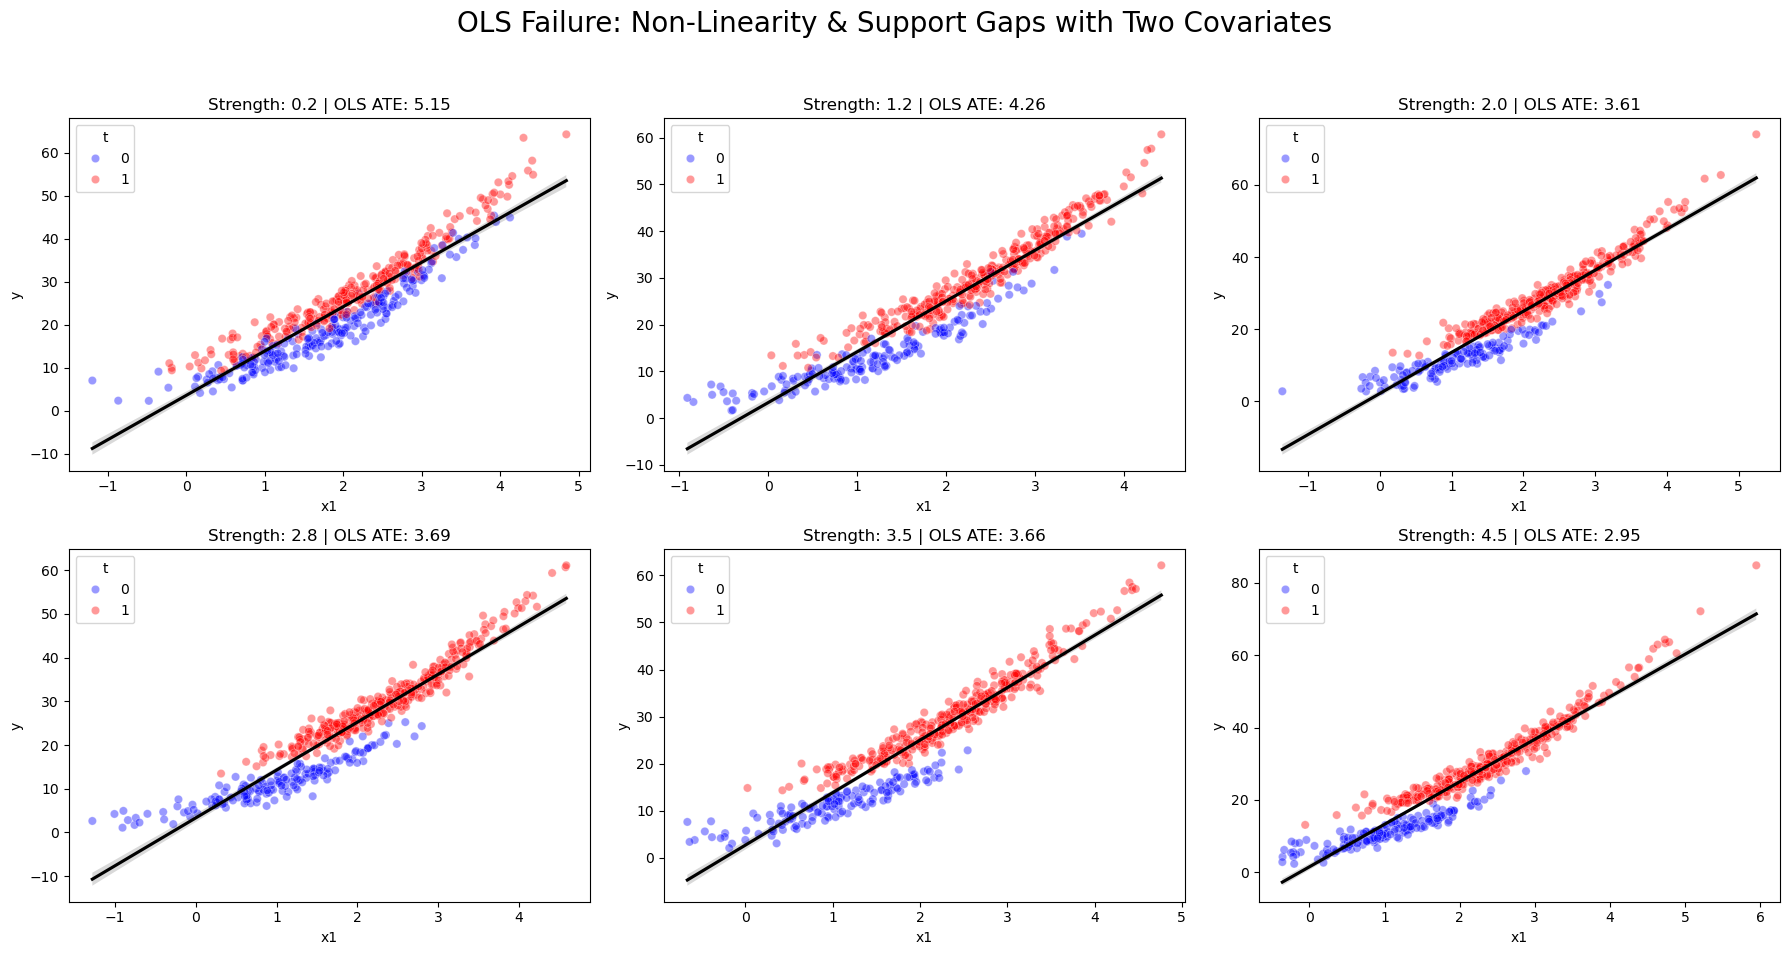

In [5]:
strengths = [0.2, 1.2, 2.0, 2.8, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    # 1. Generate data with x1 and x2
    df = generate_research_data(n=500, overlap_strength=s)
    
    # 2. Update OLS to control for both covariates
    ols_model = smf.ols('y ~ t + x1 + x2', data=df).fit()
    ate_val = ols_model.params['t']
    
    # 3. Plotting x1 vs y (mentioning x2 is controlled for)
    sns.scatterplot(data=df, x='x1', y='y', hue='t', ax=axes[i], palette=['blue', 'red'], alpha=0.4)
    
    # We plot the regression line against x1 specifically
    sns.regplot(data=df, x='x1', y='y', scatter=False, color='black', ax=axes[i])
    
    axes[i].set_title(f"Strength: {s} | OLS ATE: {ate_val:.2f}")

plt.suptitle("OLS Failure: Non-Linearity & Support Gaps with Two Covariates", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

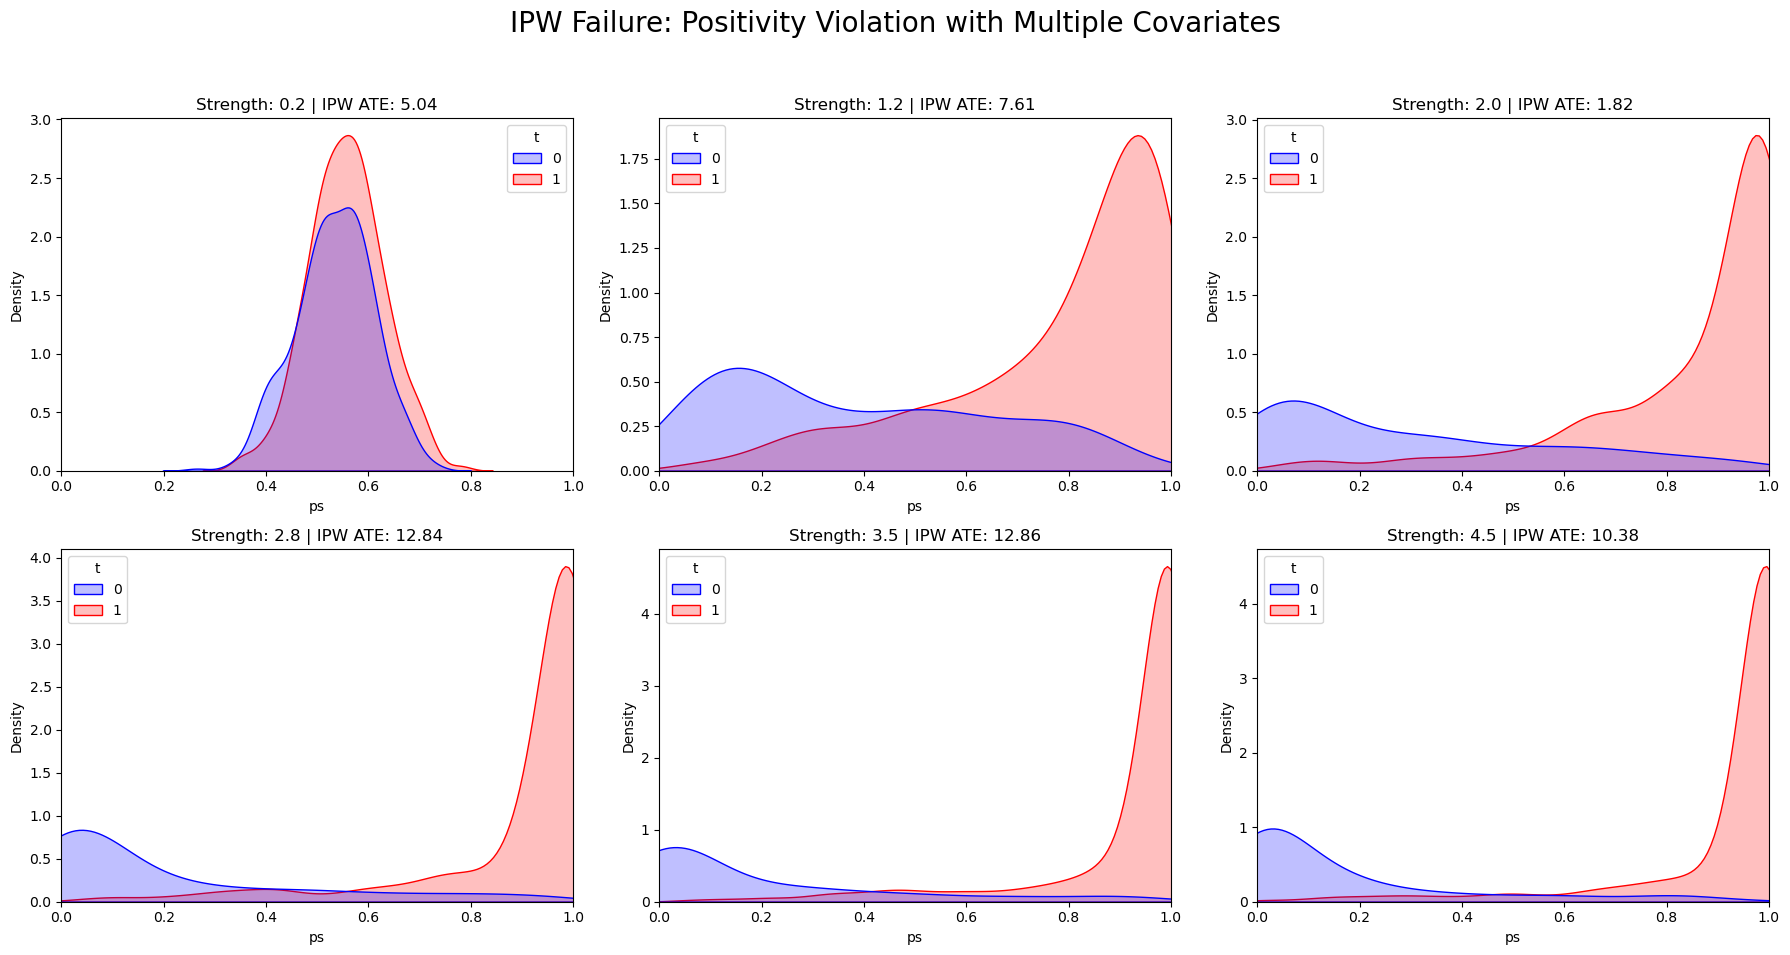

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    # 1. Generate data with x1 and x2
    df = generate_research_data(n=1000, overlap_strength=s)
    
    # 2. Fit Propensity Model using BOTH covariates
    covs = ['x1', 'x2']
    lr = LogisticRegression(penalty=None).fit(df[covs], df['t'])
    df['ps'] = lr.predict_proba(df[covs])[:, 1]
    
    # 3. Visualization of Propensity Overlap
    sns.kdeplot(data=df, x='ps', hue='t', fill=True, ax=axes[i], palette=['blue', 'red'])
    
    # 4. Calculate IPW ATE (Hajek version)
    w1, w0 = df['t']/df['ps'], (1-df['t'])/(1-df['ps'])
    ipw_val = (df['y']*w1).sum()/w1.sum() - (df['y']*w0).sum()/w0.sum()
    
    axes[i].set_title(f"Strength: {s} | IPW ATE: {ipw_val:.2f}")
    axes[i].set_xlim(0, 1)

plt.suptitle("IPW Failure: Positivity Violation with Multiple Covariates", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

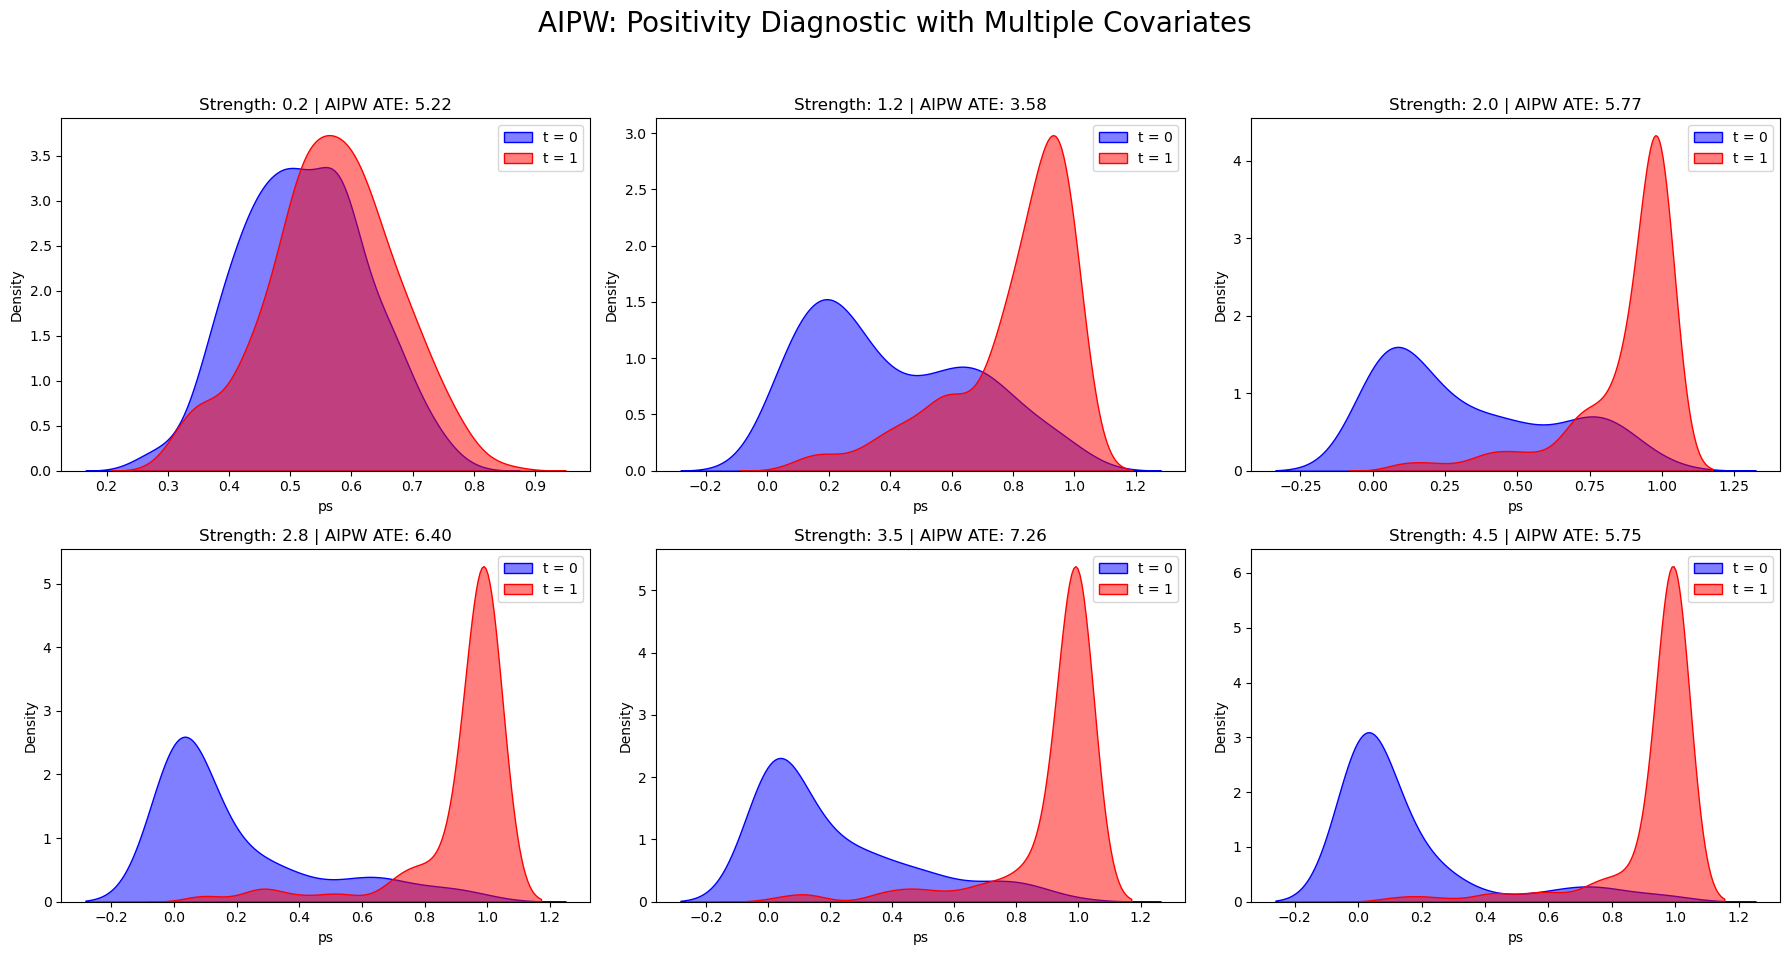

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
covs = ['x1', 'x2']

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)

    # --- Propensity model using BOTH covariates ---
    lr = LogisticRegression(penalty=None).fit(df[covs], df['t'])
    ps = lr.predict_proba(df[covs])[:, 1]
    ps_clip = np.clip(ps, 0.001, 0.999)

    # --- Outcome models using BOTH covariates ---
    m1 = LinearRegression().fit(df[df.t==1][covs], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][covs], df[df.t==0]['y'])

    mu1 = m1.predict(df[covs])
    mu0 = m0.predict(df[covs])

    # --- AIPW estimator (Doubly Robust) ---
    aipw_ate = (
        (mu1 - mu0)
        + df.t * (df.y - mu1) / ps_clip
        - (1 - df.t) * (df.y - mu0) / (1 - ps_clip)
    ).mean()

    # --- KDE of propensity scores (diagnostic) ---
    df_plot = df.copy()
    df_plot["ps"] = ps

    sns.kdeplot(data=df_plot[df_plot.t == 0], x="ps", fill=True, alpha=0.5, 
                label="t = 0", color="blue", ax=axes[i])
    sns.kdeplot(data=df_plot[df_plot.t == 1], x="ps", fill=True, alpha=0.5, 
                label="t = 1", color="red", ax=axes[i])

    axes[i].set_title(f"Strength: {s} | AIPW ATE: {aipw_ate:.2f}")
    axes[i].set_xlabel("ps")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("AIPW: Positivity Diagnostic with Multiple Covariates", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

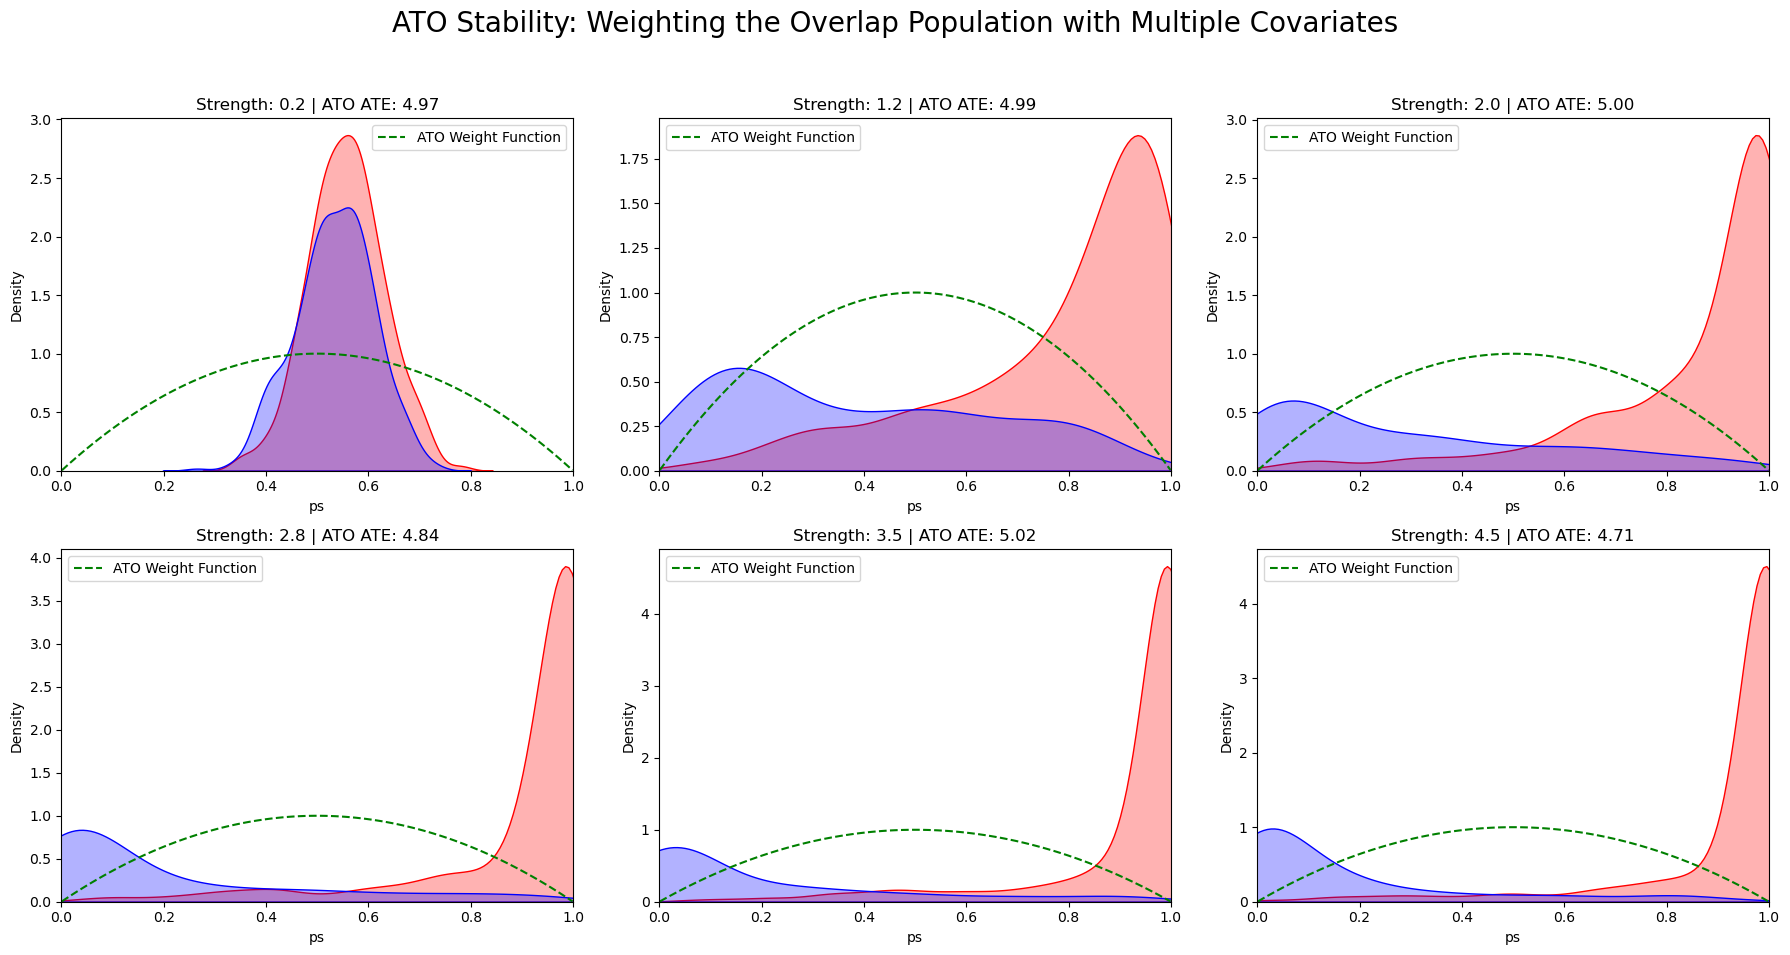

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
covs = ['x1', 'x2']

for i, s in enumerate(strengths):
    # 1. Generate data with two covariates
    df = generate_research_data(n=1000, overlap_strength=s)
    
    # 2. Fit Propensity Model using BOTH covariates
    lr = LogisticRegression(penalty=None).fit(df[covs], df['t'])
    df['ps'] = lr.predict_proba(df[covs])[:, 1]
    
    # 3. Plot the Density of Treated vs Control
    sns.kdeplot(data=df, x='ps', hue='t', fill=True, ax=axes[i], palette=['blue', 'red'], alpha=0.3)
    
    # 4. Overlay the ATO Weighting Curve
    # This remains the same as it is a function of the probability (ps)
    ps_range = np.linspace(0.001, 0.999, 100)
    ato_weights_curve = 4 * ps_range * (1 - ps_range) 
    axes[i].plot(ps_range, ato_weights_curve, color='green', linestyle='--', label='ATO Weight Function')
    
    # 5. Calculate ATO ATE using Hajek Weights
    w1, w0 = df['t'] * (1 - df['ps']), (1 - df['t']) * df['ps']
    ato_val = (df['y'] * w1).sum() / w1.sum() - (df['y'] * w0).sum() / w0.sum()
    
    axes[i].set_title(f"Strength: {s} | ATO ATE: {ato_val:.2f}")
    axes[i].set_xlim(0, 1)
    axes[i].legend()

plt.suptitle("ATO Stability: Weighting the Overlap Population with Multiple Covariates", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

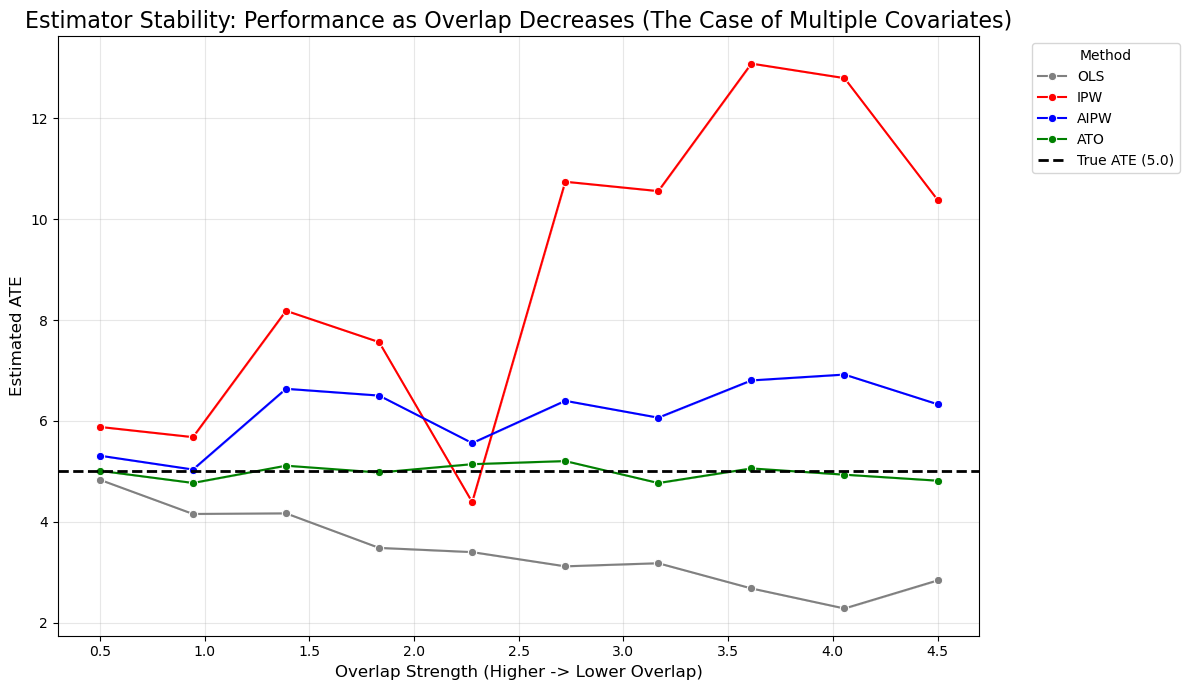

In [9]:
overlap_range = np.linspace(0.5, 4.5, 10)
results = []

# Simulation loop to gather data for the final plot
for s in overlap_range:
    for _ in range(15):  # Multiple runs per strength for error bars
        df = generate_research_data(n=1000, overlap_strength=s)
        ests = get_all_estimates(df)
        for name, val in ests.items():
            results.append({'Strength': s, 'Method': name, 'ATE': val})

df_res = pd.DataFrame(results)

# Final Visualization
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_res[df_res.Method.isin(['OLS', 'IPW', 'AIPW', 'ATO'])], 
    x='Strength', 
    y='ATE', 
    hue='Method', 
    marker='o', 
    errorbar='sd',
    palette={'OLS': 'gray', 'IPW': 'red', 'AIPW': 'blue', 'ATO': 'green'}
)

plt.axhline(5.0, color='black', linestyle='--', linewidth=2, label='True ATE (5.0)')

plt.title("Estimator Stability: Performance as Overlap Decreases (The Case of Multiple Covariates)", fontsize=16)
plt.xlabel("Overlap Strength (Higher -> Lower Overlap)", fontsize=12)
plt.ylabel("Estimated ATE", fontsize=12)
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()